In [2]:
import pandas as pd
import matplotlib.pyplot as plt

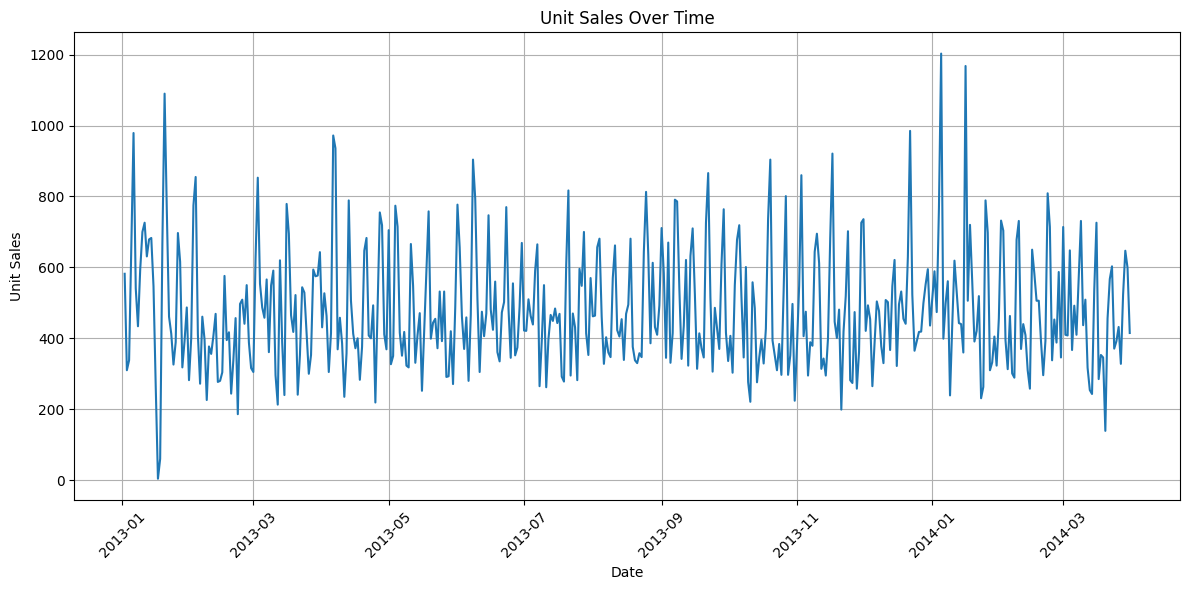

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Read CSV
timeseries = pd.read_csv('C:/Users/jmofl/PycharmProjects/TimeSeriesProject_Feb_2026/data/timeseries.csv')

# Convert date and set as index
timeseries['date'] = pd.to_datetime(timeseries['date'])
timeseries.set_index('date', inplace=True)

# Plot
plt.figure(figsize=(12,6))
plt.plot(timeseries.index, timeseries['unit_sales'])
plt.title('Unit Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# outliers

In [4]:
# Calculate z-scores to identify outliers
from scipy import stats
import numpy as np
z_scores = np.abs(stats.zscore(timeseries['unit_sales']))
outliers = timeseries[z_scores > 5]
outliers


,unit_sales
date,


# Missing Values


In [5]:
# Check for missing values
missing_values = timeseries.isnull().sum()
missing_values

unit_sales    0
dtype: int64

# Date range index

In [36]:
pd.date_range(start=timeseries.index.min(), end=timeseries.index.max())

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', length=454, freq='D')

# index

In [37]:
timeseries.index

DatetimeIndex(['2013-01-02', '2013-01-03', '2013-01-04', '2013-01-05',
               '2013-01-06', '2013-01-07', '2013-01-08', '2013-01-09',
               '2013-01-10', '2013-01-11',
               ...
               '2014-03-22', '2014-03-23', '2014-03-24', '2014-03-25',
               '2014-03-26', '2014-03-27', '2014-03-28', '2014-03-29',
               '2014-03-30', '2014-03-31'],
              dtype='datetime64[us]', name='date', length=452, freq=None)

In [7]:
# Check if all days are present
date_range = pd.date_range(start=timeseries.index.min(), end=timeseries.index.max())
missing_dates = date_range.difference(timeseries.index)
missing_dates

DatetimeIndex(['2013-12-25', '2014-01-01'], dtype='datetime64[ns]', freq=None)

In [8]:
# Solve missing dates by forward filling
df = timeseries.reindex(date_range)
timeseries

,unit_sales
date,
2013-01-02,582.0
2013-01-03,310.0
2013-01-04,338.0
2013-01-05,654.0
2013-01-06,979.0
...,...
2014-03-27,328.0
2014-03-28,523.0
2014-03-29,647.0


In [46]:
# Fill missing unit_sales with forward fill
timeseries['unit_sales'] = timeseries['unit_sales'].ffill()

# Summary Statistics

In [10]:

summary_stats = timeseries['unit_sales'].describe().round(1)
summary_stats

count     452.0
mean      480.1
std       170.8
min         4.0
25%       358.0
50%       445.5
75%       578.2
max      1203.0
Name: unit_sales, dtype: float64

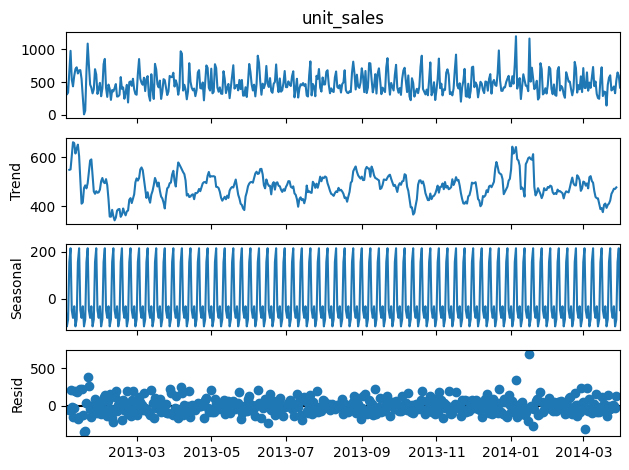

In [47]:

from statsmodels.tsa.seasonal import seasonal_decompose

# Set frequenc to daily
timeseries = timeseries.asfreq('D')  # This is done for seasonal decomposition to infere seasonal patterns
# Perform seasonal decomposition
decomposition = seasonal_decompose(timeseries['unit_sales'], model='additive')
decomposition.plot()
plt.show()

## Stationarity Test


In [53]:

from statsmodels.tsa.stattools import adfuller
# Perform Augmented Dickey-Fuller test
adf_result = adfuller(timeseries['unit_sales'])
adf_result_dict = {
    'ADF Statistic': adf_result[0],
    'p-value': adf_result[1],
    'Critical Values': adf_result[4]
}
adf_result_dict



{'ADF Statistic': np.float64(-5.051243167393034),
 'p-value': np.float64(1.755430513962352e-05),
 'Critical Values': {'1%': np.float64(-3.4454725477848998),
  '5%': np.float64(-2.8682072297316794),
  '10%': np.float64(-2.570321396485665)}}

## Autocorrelation Analysis


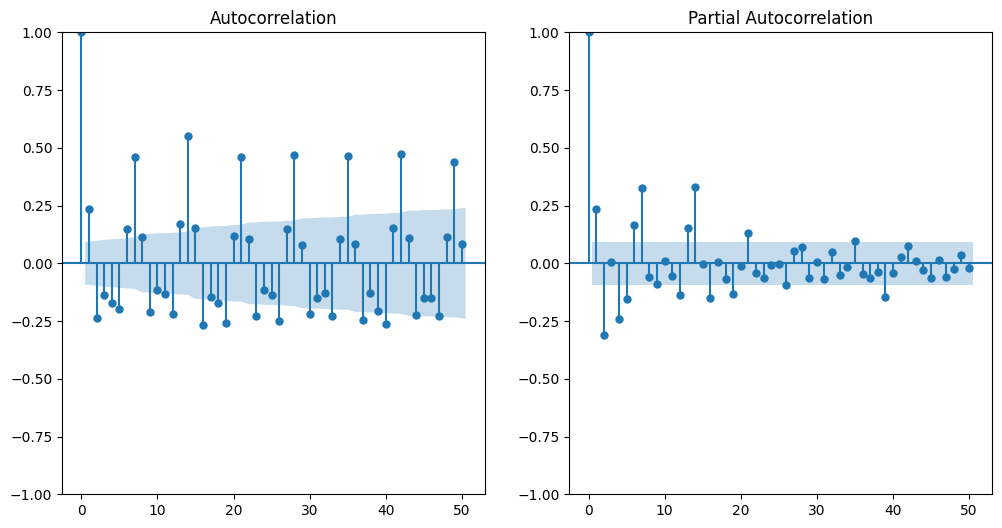

In [54]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# Plot ACF and PACF
plt.figure(figsize=(12, 6))
plt.subplot(121)
plot_acf(timeseries['unit_sales'], ax=plt.gca(), lags=50)
plt.subplot(122)
plot_pacf(timeseries['unit_sales'], ax=plt.gca(), lags=50)
plt.show()



## Save cleaned data

In [56]:
# Save the cleaned data

timeseries.index.name = "date"
import os
timeseries.to_csv('C:/Users/jmofl/PycharmProjects/TimeSeriesProject_Feb_2026/data/cleaned_timeseries.csv', index=True)

